# Left-vs-Right laterality analysis (VinDr bilateral mammography)

This notebook characterizes the **paired, within-study** difference between a patient's
left-CC and right-CC mammogram in the **model-aligned frame** (right breast flipped +
width-cropped, normalized to `[-1, 1]` — exactly what CUT/FastCUT sees), restricted to the
**normal** cohort (`no_finding`) and **stratified by breast density**.

It then asks: **does the trained generator close the left->right gap?** by comparing the
original paired gap `d(real_A, real_B)` against the post-translation gap `d(fake_B, real_B)`
using saved test outputs.

**Sections**

- **0** — Config & setup
- **1** — Build the paired cohort + per-study features
- **2** — Cohort summary
- **3** — Visual L-vs-R (samples, mean images, difference maps)
- **4** — Statistical L-vs-R (paired tests, Bland-Altman, image-distance metrics)
- **5** — Model-output comparison: does CUT close the gap?
- **6** — Summary
- *Appendix* — optional live `netG` inference

## 0. Config & setup

In [2]:
import os, sys, glob, warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

warnings.filterwarnings("ignore")
np.random.seed(0)

# --- locate repo root (so `import data.bilateral` works) ---
REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "data" / "bilateral.py").exists():
    for p in [REPO_ROOT, *REPO_ROOT.parents]:
        if (p / "data" / "bilateral.py").exists():
            REPO_ROOT = p
            break
sys.path.insert(0, str(REPO_ROOT))

# --- data / artifact locations ---
DATA_ROOT       = "/home/valery/datasets/vindr/images"
ANNOTATIONS_CSV = "/home/valery/datasets/vindr/finding_annotations.csv"

# --- model-aligned frame (must match training transform) ---
SPLIT          = "test"          # saved model results below are all test-split
BILATERAL_SIZE = (512, 360)      # (H, W) before crop
CROP_WIDTH     = 360             # keep chest-wall columns
FLIP_RIGHT     = True            # right breast flipped to left orientation
FINDING_FILTER = "no_finding"    # normals (training cohort)

# --- saved model outputs ---
# A *bidirectional* run carries all four channels (real_A, real_B, fake_B=G(L), fake_A=G(R)),
# which section 5 needs for the G(L)-vs-G(R) comparison. This run is test-split / no_finding,
# matching the cohort above. A unidirectional run (real_A/fake_B/real_B only) also works —
# section 5 simply skips the third comparison.
RESULTS_DIR = REPO_ROOT / ("results-bd/fastcut_results/"
    "vindr_bilateral_ddp_g1_nce5_m_bd_recon_l1100_l20_20260617/test_latest/images")

FIG_DIR = REPO_ROOT / "figures/laterality_analysis-patchnce"
FIG_DIR.mkdir(parents=True, exist_ok=True)

DENSITY_ORDER = ["DENSITY A", "DENSITY B", "DENSITY C", "DENSITY D"]
MAX_STUDIES   = None             # set to an int for a quick subsample

print("repo root  :", REPO_ROOT)
print("results dir:", RESULTS_DIR, "(exists:", RESULTS_DIR.exists(), ")")

repo root  : /home/valery/phd/contrastive-unpaired-translation
results dir: /home/valery/phd/contrastive-unpaired-translation/results-bd/fastcut_results/vindr_bilateral_ddp_g1_nce5_m_bd_recon_l1100_l20_20260617/test_latest/images (exists: True )


In [3]:
# Reuse the project's loaders so geometry/normalization match training exactly.
from data.bilateral import BilateralDataset, _load_mask, _mask_path

ds = BilateralDataset(
    data_root=DATA_ROOT,
    annotations_csv=ANNOTATIONS_CSV,
    split=SPLIT,
    img_size=BILATERAL_SIZE,
    flip_right=FLIP_RIGHT,
    crop_width=CROP_WIDTH,
    finding_filter=FINDING_FILTER,
)
print("paired studies:", len(ds), "| output size:", ds.img_size, "-> crop_width", ds.crop_width)

# image_id -> metadata (density / birads / study / split)
ann = pd.read_csv(ANNOTATIONS_CSV)
meta = (ann.drop_duplicates("image_id")
           .set_index("image_id")[["study_id", "laterality", "view_position",
                                    "breast_density", "breast_birads",
                                    "finding_categories", "split"]])
print("annotation rows:", len(ann), "| unique image ids:", len(meta))

[BilateralDataset] Loaded 813 paired studies (split=test)
paired studies: 813 | output size: (512, 360) -> crop_width 360
annotation rows: 20487 | unique image ids: 20000


Helpers — all comparisons are done in the model-aligned `[-1, 1]` frame.

In [4]:
from scipy import stats as sstats
from scipy.stats import wilcoxon, ttest_rel
from skimage.feature import graycomatrix, graycoprops
from skimage.metrics import structural_similarity as ssim

def t2a(t):
    "tensor [1,H,W] in [-1,1] -> HxW float32 array"
    return t.squeeze(0).numpy() if hasattr(t, "numpy") else np.asarray(t)

def to_unit(img):  return (img + 1.0) / 2.0                       # [-1,1] -> [0,1]
def to_uint8(img): return np.clip((img + 1.0) * 127.5, 0, 255).astype(np.uint8)

def load_pair_aligned(idx):
    "Paired (left, right) arrays in [-1,1], model-aligned (right flipped+cropped)."
    l, r = ds[idx]
    return t2a(l), t2a(r)

def foreground_mask(image_path, flip, img_arr):
    "Precomputed breast mask (same geometry); Otsu fallback if missing."
    m = _load_mask(_mask_path(Path(image_path)), ds.img_size, flip, ds.crop_width)
    if m is not None:
        return t2a(m) > 0.5
    u = to_uint8(img_arr)
    thr, _ = cv2.threshold(u, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return u > thr

def image_features(img, mask):
    "Scalar intensity/texture/size features over the breast foreground."
    u = to_uint8(img).astype(np.float64)
    fg = u[mask] if mask.any() else u.ravel()
    gx = cv2.Sobel(u, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(u, cv2.CV_64F, 0, 1, ksize=3)
    gmag = np.sqrt(gx * gx + gy * gy)
    # GLCM texture on a 32-level quantization within the breast bounding box
    q = (to_uint8(img).astype(np.uint16) // 8).astype(np.uint8)
    ys, xs = np.where(mask)
    if ys.size:
        q = q[ys.min():ys.max() + 1, xs.min():xs.max() + 1]
    glcm = graycomatrix(q, distances=[1], angles=[0, np.pi / 2],
                        levels=32, symmetric=True, normed=True)
    return {
        "mean": fg.mean(), "std": fg.std(), "median": np.median(fg),
        "p10": np.percentile(fg, 10), "p90": np.percentile(fg, 90),
        "skew": sstats.skew(fg),
        "fg_area_px": float(mask.sum()), "fg_area_frac": float(mask.mean()),
        "grad_mag": float(gmag[mask].mean()) if mask.any() else float(gmag.mean()),
        "glcm_contrast": float(graycoprops(glcm, "contrast").mean()),
        "glcm_homogeneity": float(graycoprops(glcm, "homogeneity").mean()),
    }

FEATURES = ["mean", "std", "median", "p10", "p90", "skew",
            "fg_area_px", "fg_area_frac", "grad_mag",
            "glcm_contrast", "glcm_homogeneity"]

def pair_distances(a, b):
    "Image-level distance between two [-1,1] arrays. SSIM up, others down."
    a01, b01 = to_unit(a), to_unit(b)
    s = ssim(a01, b01, data_range=1.0)
    l1 = float(np.abs(a01 - b01).mean())
    l2 = float(np.sqrt(((a01 - b01) ** 2).mean()))
    ha = cv2.calcHist([to_uint8(a)], [0], None, [64], [0, 256]).ravel()
    hb = cv2.calcHist([to_uint8(b)], [0], None, [64], [0, 256]).ravel()
    ha /= ha.sum() + 1e-8; hb /= hb.sum() + 1e-8
    chi = float(0.5 * np.sum((ha - hb) ** 2 / (ha + hb + 1e-8)))
    return {"ssim": s, "l1": l1, "l2": l2, "chi2": chi}

## 1. Build the paired cohort + per-study features

In [5]:
# Single pass over the cohort: per-side features, per-study L-vs-R distances,
# and accumulators for mean images + foreground intensity histograms (overall + per density).
feat_rows, dist_rows = [], []
acc = {}  # key("ALL" / density) -> running sums

def get_acc(key, shape):
    if key not in acc:
        acc[key] = dict(L=np.zeros(shape), R=np.zeros(shape), n=0,
                        hL=np.zeros(256), hR=np.zeros(256))
    return acc[key]

n = len(ds) if MAX_STUDIES is None else min(MAX_STUDIES, len(ds))
for idx in range(n):
    lp, rp = ds.pairs[idx]
    L, R = load_pair_aligned(idx)
    mL = foreground_mask(lp, False, L)
    mR = foreground_mask(rp, FLIP_RIGHT, R)

    lid = Path(lp).stem
    sid = Path(lp).parent.name
    dens = meta.at[lid, "breast_density"] if lid in meta.index else None
    bir  = meta.at[lid, "breast_birads"]  if lid in meta.index else None
    dens_key = dens if isinstance(dens, str) else "UNKNOWN"

    fL, fR = image_features(L, mL), image_features(R, mR)
    feat_rows.append({"study_id": sid, "image_id": lid, "side": "L",
                      "density": dens, "birads": bir, **fL})
    feat_rows.append({"study_id": sid, "image_id": lid, "side": "R",
                      "density": dens, "birads": bir, **fR})

    d = pair_distances(L, R)
    dist_rows.append({"study_id": sid, "image_id": lid, "idx": idx,
                      "density": dens, "birads": bir, **d})

    for key in ("ALL", dens_key):
        a = get_acc(key, L.shape)
        a["L"] += to_unit(L); a["R"] += to_unit(R); a["n"] += 1
        a["hL"] += np.bincount(to_uint8(L)[mL], minlength=256)
        a["hR"] += np.bincount(to_uint8(R)[mR], minlength=256)

    if (idx + 1) % 100 == 0:
        print(f"  processed {idx + 1}/{n}")

feat = pd.DataFrame(feat_rows)
dist = pd.DataFrame(dist_rows)
print("feat:", feat.shape, "| dist:", dist.shape)
feat.head()

  processed 100/813
  processed 200/813
  processed 300/813
  processed 400/813
  processed 500/813
  processed 600/813
  processed 700/813
  processed 800/813
feat: (1626, 16) | dist: (813, 9)


,study_id,image_id,side,density,birads,mean,std,median,p10,p90,skew,fg_area_px,fg_area_frac,grad_mag,glcm_contrast,glcm_homogeneity
0,d0accde54989134aceb8778395212576,03411e5d4d10b79ba7afd6361dcd4f95,L,DENSITY C,BI-RADS 1,92.533396,37.863204,86.0,46.0,145.0,0.235522,76116.0,0.412956,49.076155,0.970218,0.749110
1,d0accde54989134aceb8778395212576,03411e5d4d10b79ba7afd6361dcd4f95,R,DENSITY C,BI-RADS 1,96.466914,41.077177,87.0,49.0,157.0,0.453384,75817.0,0.411334,47.753098,0.889701,0.751494
2,d0322ac75743dc7de6f530b9780d9008,df3378c776a89a1166bb0bd57e0812a3,L,DENSITY C,BI-RADS 1,81.420399,32.292249,86.0,30.0,119.0,-0.360709,103259.0,0.560216,45.950289,1.123204,0.711460
3,d0322ac75743dc7de6f530b9780d9008,df3378c776a89a1166bb0bd57e0812a3,R,DENSITY C,BI-RADS 1,81.231804,33.079290,86.0,31.0,120.0,-0.252835,91271.0,0.495177,46.159129,1.120725,0.716111
4,8492112cba1ba5926caf14e5805ef0b3,bfda0deaefee87efb58543e703364a43,L,DENSITY C,BI-RADS 1,94.149471,34.344944,89.0,51.0,142.0,0.530835,112423.0,0.609934,56.485111,1.365981,0.698513


## 2. Cohort summary

paired studies: 813
L/R row counts: {'L': 813, 'R': 813}


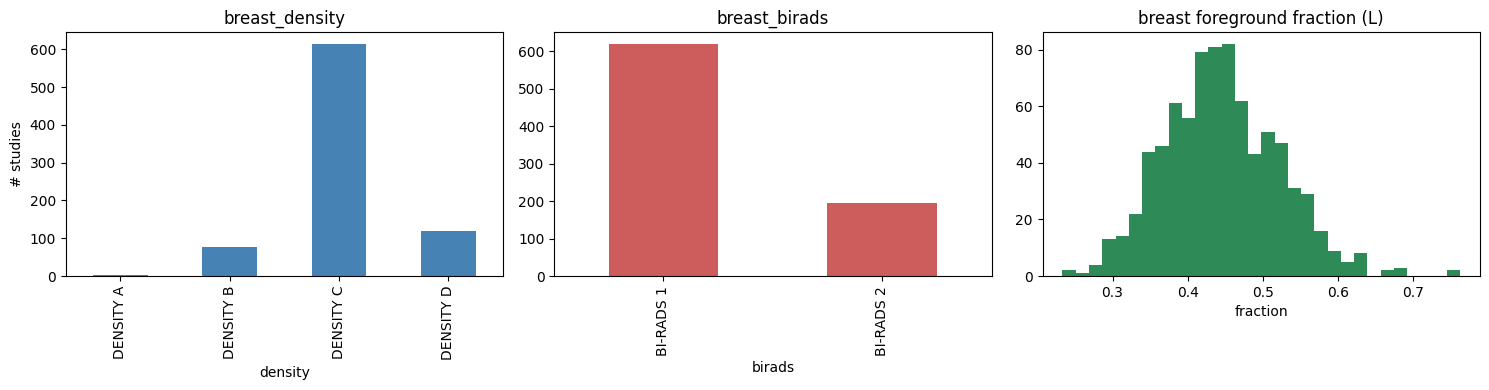

,count,mean,std
density,,,
DENSITY A,4.0,0.464476,0.111525
DENSITY B,77.0,0.456434,0.074698
DENSITY C,614.0,0.442346,0.074454
DENSITY D,118.0,0.455470,0.088289


In [6]:
study = feat[feat.side == "L"].copy()
print("paired studies:", len(study))
print("L/R row counts:", feat.side.value_counts().to_dict())

dens_counts = study["density"].value_counts().reindex(DENSITY_ORDER).fillna(0)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
dens_counts.plot.bar(ax=axes[0], color="steelblue")
axes[0].set_title("breast_density"); axes[0].set_ylabel("# studies")
study["birads"].value_counts().sort_index().plot.bar(ax=axes[1], color="indianred")
axes[1].set_title("breast_birads")
axes[2].hist(study["fg_area_frac"], bins=30, color="seagreen")
axes[2].set_title("breast foreground fraction (L)"); axes[2].set_xlabel("fraction")
plt.tight_layout(); plt.savefig(FIG_DIR / "cohort_summary.png", dpi=120); plt.show()

display(study.groupby("density")["fg_area_frac"].describe()[["count", "mean", "std"]])

## 3. Visual L-vs-R (paired, model-aligned)

Right breasts are flipped + cropped to the left frame, so `L` and `R` overlay directly —
no registration needed.

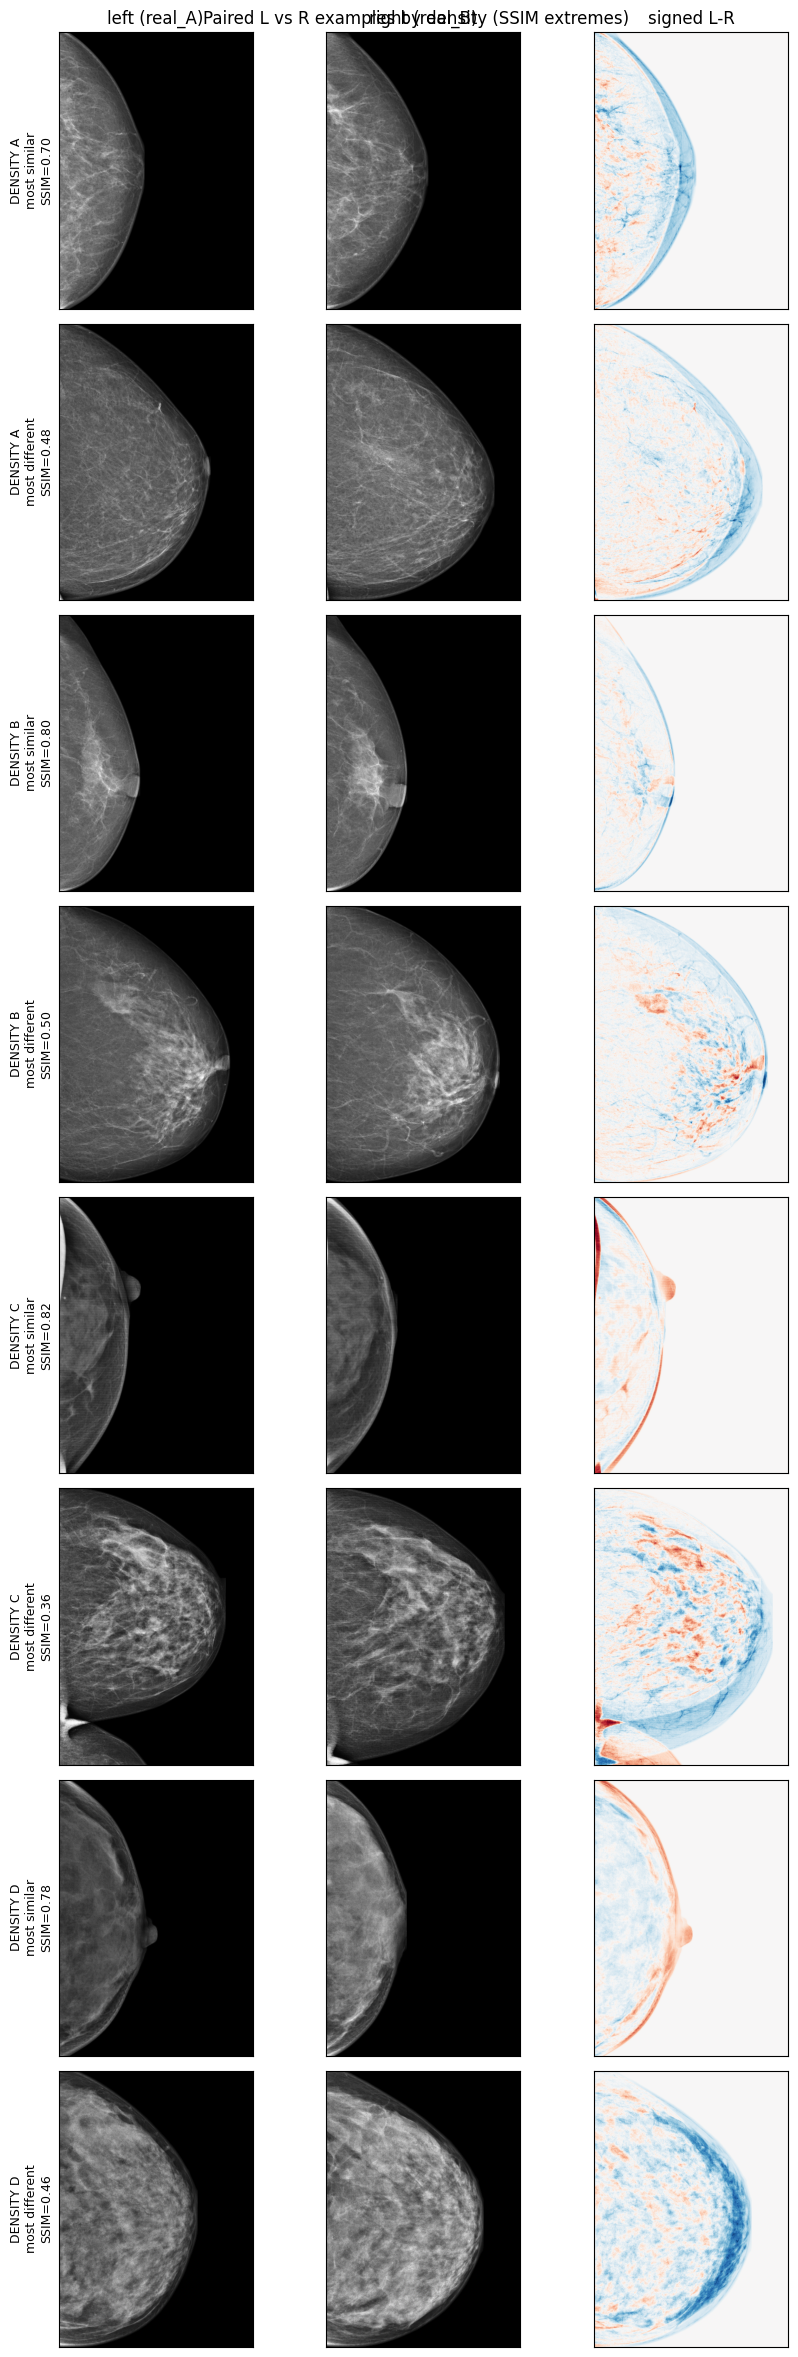

In [7]:
# Example triples: most-similar and most-different study per density (by SSIM).
def show_triples(idxs, titles, suptitle, fname):
    k = len(idxs)
    fig, axes = plt.subplots(k, 3, figsize=(9, 3 * k))
    axes = np.atleast_2d(axes)
    for row, (ix, ttl) in enumerate(zip(idxs, titles)):
        L, R = load_pair_aligned(ix)
        diff = to_unit(L) - to_unit(R)
        axes[row, 0].imshow(to_uint8(L), cmap="gray"); axes[row, 0].set_ylabel(ttl, fontsize=9)
        axes[row, 1].imshow(to_uint8(R), cmap="gray")
        m = np.abs(diff).max()
        axes[row, 2].imshow(diff, cmap="RdBu_r", vmin=-m, vmax=m)
        if row == 0:
            for c, t in enumerate(["left (real_A)", "right (real_B)", "signed L-R"]):
                axes[row, c].set_title(t)
        for c in range(3):
            axes[row, c].set_xticks([]); axes[row, c].set_yticks([])
    fig.suptitle(suptitle); plt.tight_layout()
    plt.savefig(FIG_DIR / fname, dpi=120); plt.show()

picks, titles = [], []
for dkey in DENSITY_ORDER:
    sub = dist[dist.density == dkey]
    if len(sub) == 0:
        continue
    hi = sub.loc[sub.ssim.idxmax()]; lo = sub.loc[sub.ssim.idxmin()]
    picks += [int(hi["idx"]), int(lo["idx"])]
    titles += [f"{dkey}\nmost similar\nSSIM={hi.ssim:.2f}",
               f"{dkey}\nmost different\nSSIM={lo.ssim:.2f}"]
show_triples(picks, titles, "Paired L vs R examples by density (SSIM extremes)",
             "examples_by_density.png")

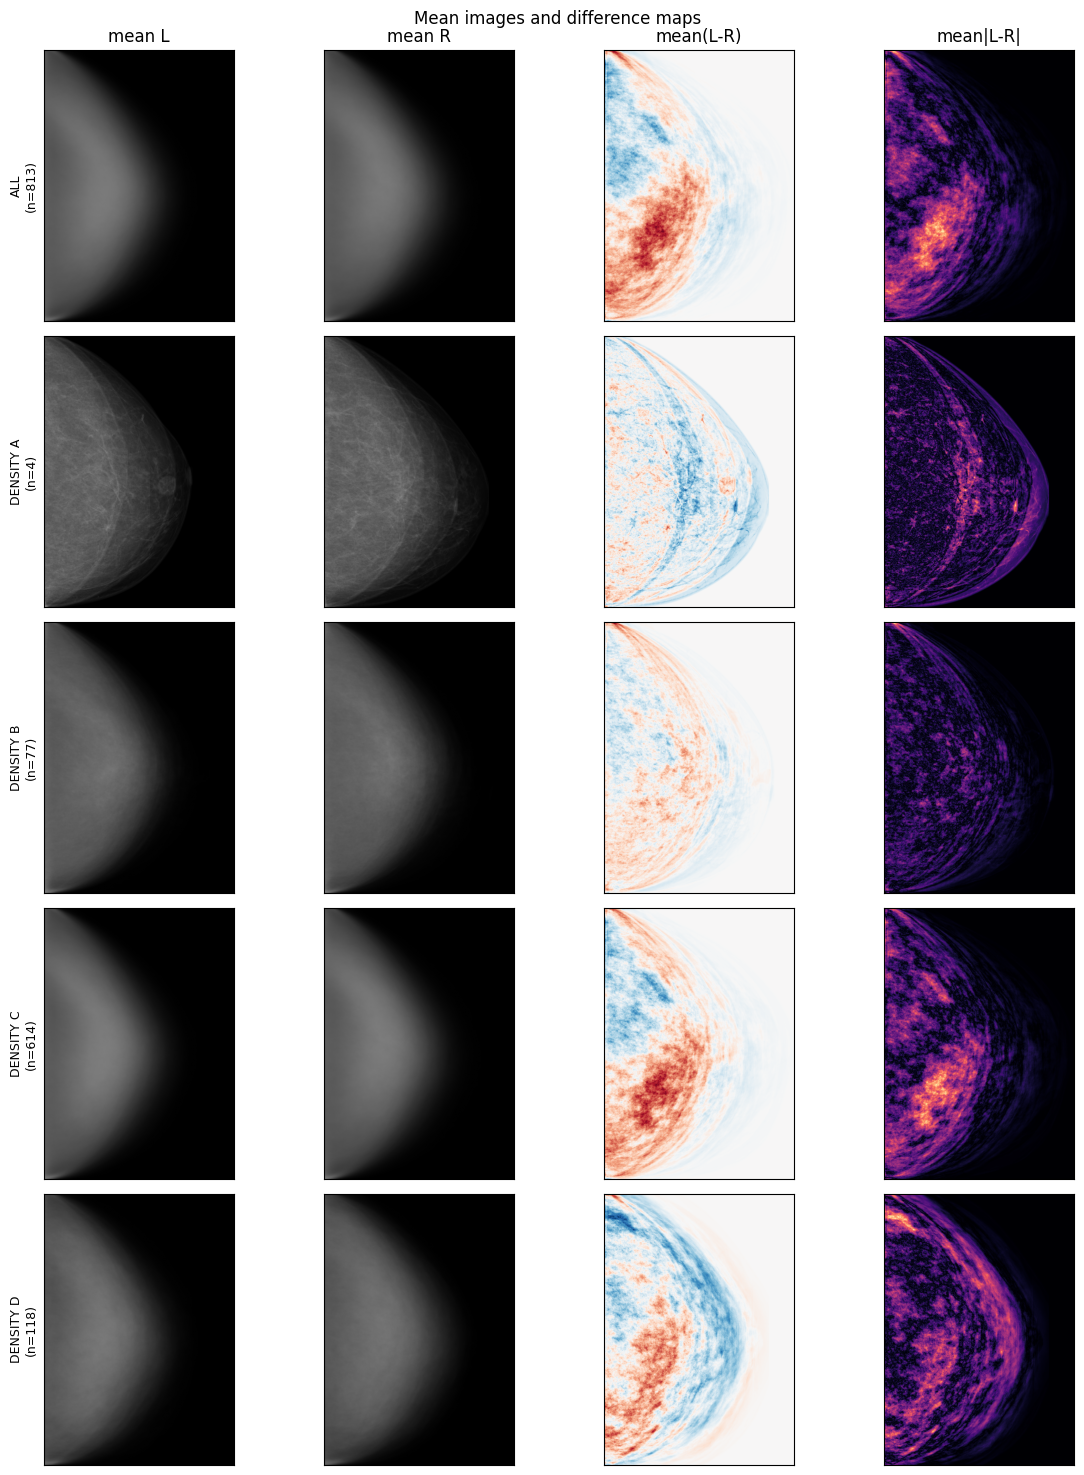

In [8]:
# Mean images and mean difference maps (overall + per density).
def mean_panel(key):
    a = acc.get(key)
    if a is None or a["n"] == 0:
        return None
    return a["L"] / a["n"], a["R"] / a["n"], a["n"]

keys = ["ALL"] + [d for d in DENSITY_ORDER if d in acc]
fig, axes = plt.subplots(len(keys), 4, figsize=(12, 3 * len(keys)))
axes = np.atleast_2d(axes)
for row, key in enumerate(keys):
    mL, mR, cnt = mean_panel(key)
    sdiff = mL - mR
    m = np.abs(sdiff).max() + 1e-8
    axes[row, 0].imshow(mL, cmap="gray", vmin=0, vmax=1)
    axes[row, 1].imshow(mR, cmap="gray", vmin=0, vmax=1)
    axes[row, 2].imshow(sdiff, cmap="RdBu_r", vmin=-m, vmax=m)
    axes[row, 3].imshow(np.abs(sdiff), cmap="magma")
    axes[row, 0].set_ylabel(f"{key}\n(n={cnt})", fontsize=9)
    if row == 0:
        for c, t in enumerate(["mean L", "mean R", "mean(L-R)", "mean|L-R|"]):
            axes[row, c].set_title(t)
    for c in range(4):
        axes[row, c].set_xticks([]); axes[row, c].set_yticks([])
fig.suptitle("Mean images and difference maps"); plt.tight_layout()
plt.savefig(FIG_DIR / "mean_difference_maps.png", dpi=120); plt.show()

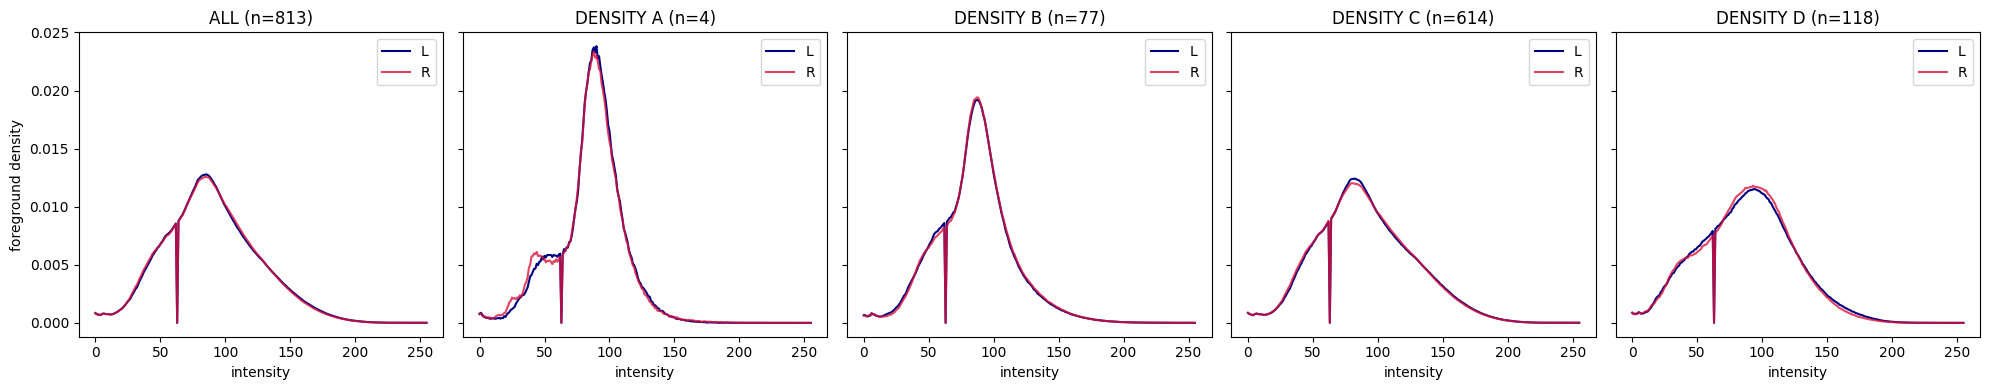

In [9]:
# Foreground intensity histograms (L vs R), overall and per density.
keys = ["ALL"] + [d for d in DENSITY_ORDER if d in acc]
fig, axes = plt.subplots(1, len(keys), figsize=(4 * len(keys), 4), sharey=True)
axes = np.atleast_1d(axes)
bins = np.arange(256)
for ax, key in zip(axes, keys):
    a = acc[key]
    hL = a["hL"] / a["hL"].sum(); hR = a["hR"] / a["hR"].sum()
    ax.plot(bins, hL, label="L", color="navy")
    ax.plot(bins, hR, label="R", color="crimson", alpha=0.8)
    ax.set_title(f"{key} (n={a['n']})"); ax.set_xlabel("intensity"); ax.legend()
axes[0].set_ylabel("foreground density")
plt.tight_layout(); plt.savefig(FIG_DIR / "intensity_histograms.png", dpi=120); plt.show()

## 4. Statistical L-vs-R (paired)

Wilcoxon signed-rank (primary, non-parametric) and paired t-test on each feature, pooled and
per density, with Benjamini-Hochberg correction across features within each stratum.

In [10]:
def bh_correct(pvals):
    p = np.asarray(pvals, float)
    ok = ~np.isnan(p); out = np.full_like(p, np.nan)
    pe = p[ok]; n = len(pe)
    if n == 0:
        return out
    order = np.argsort(pe); ranked = np.empty(n); cummin = 1.0
    for i in range(n - 1, -1, -1):
        idx = order[i]; cummin = min(cummin, pe[idx] * n / (i + 1)); ranked[idx] = cummin
    out[ok] = np.clip(ranked, 0, 1)
    return out

def paired_stats(a, b):
    a = np.asarray(a, float); b = np.asarray(b, float)
    ok = ~(np.isnan(a) | np.isnan(b)); a, b = a[ok], b[ok]
    d = a - b
    try:
        _, wp = wilcoxon(a, b)
    except ValueError:
        wp = np.nan
    _, tp = ttest_rel(a, b)
    sd = d.std(ddof=1)
    se = sd / np.sqrt(len(d)) if len(d) else np.nan
    return {"n": len(d), "median_diff": float(np.median(d)), "mean_diff": float(d.mean()),
            "ci_low": float(d.mean() - 1.96 * se), "ci_high": float(d.mean() + 1.96 * se),
            "cohen_dz": float(d.mean() / sd) if sd > 0 else np.nan,
            "wilcoxon_p": float(wp), "ttest_p": float(tp)}

wideL = feat[feat.side == "L"].set_index("study_id")
wideR = feat[feat.side == "R"].set_index("study_id")
common = wideL.index.intersection(wideR.index)

strata = [("ALL", common)]
for dkey in DENSITY_ORDER:
    ids = study.loc[study.density == dkey, "study_id"]
    ids = common.intersection(ids)
    if len(ids) >= 5:
        strata.append((dkey, ids))

rows = []
for stratum, ids in strata:
    pcol = []
    for f in FEATURES:
        st = paired_stats(wideL.loc[ids, f].values, wideR.loc[ids, f].values)
        st.update(stratum=stratum, feature=f); rows.append(st); pcol.append(st["wilcoxon_p"])
    q = bh_correct(pcol)
    for r, qv in zip(rows[-len(FEATURES):], q):
        r["wilcoxon_q"] = float(qv)

stats_df = pd.DataFrame(rows)[["stratum", "feature", "n", "median_diff", "mean_diff",
                               "ci_low", "ci_high", "cohen_dz", "wilcoxon_p",
                               "wilcoxon_q", "ttest_p"]]
print("Pooled (ALL) — paired L vs R:")
display(stats_df[stats_df.stratum == "ALL"].round(4).set_index("feature"))

Pooled (ALL) — paired L vs R:


,stratum,n,median_diff,mean_diff,ci_low,ci_high,cohen_dz,wilcoxon_p,wilcoxon_q,ttest_p
feature,,,,,,,,,,
mean,ALL,813,0.2113,0.3621,-0.1481,0.8723,0.0488,0.0614,0.1351,0.1646
std,ALL,813,0.0855,0.1179,-0.1304,0.3661,0.0326,0.2506,0.3446,0.3525
median,ALL,813,0.0000,0.0916,-0.4421,0.6253,0.0118,0.8636,0.8636,0.7366
p10,ALL,813,0.0000,0.3502,-0.0355,0.7359,0.0624,0.0586,0.1351,0.0755
p90,ALL,813,0.0000,0.6991,-0.1234,1.5217,0.0584,0.0464,0.1351,0.0961
skew,ALL,813,0.0175,0.0158,-0.0006,0.0322,0.0662,0.0096,0.1051,0.0596
fg_area_px,ALL,813,299.0000,217.6433,-339.8713,775.1579,0.0268,0.4175,0.4593,0.4444
fg_area_frac,ALL,813,0.0016,0.0012,-0.0018,0.0042,0.0268,0.4175,0.4593,0.4444
grad_mag,ALL,813,0.1232,0.2561,-0.0255,0.5378,0.0625,0.0521,0.1351,0.0750


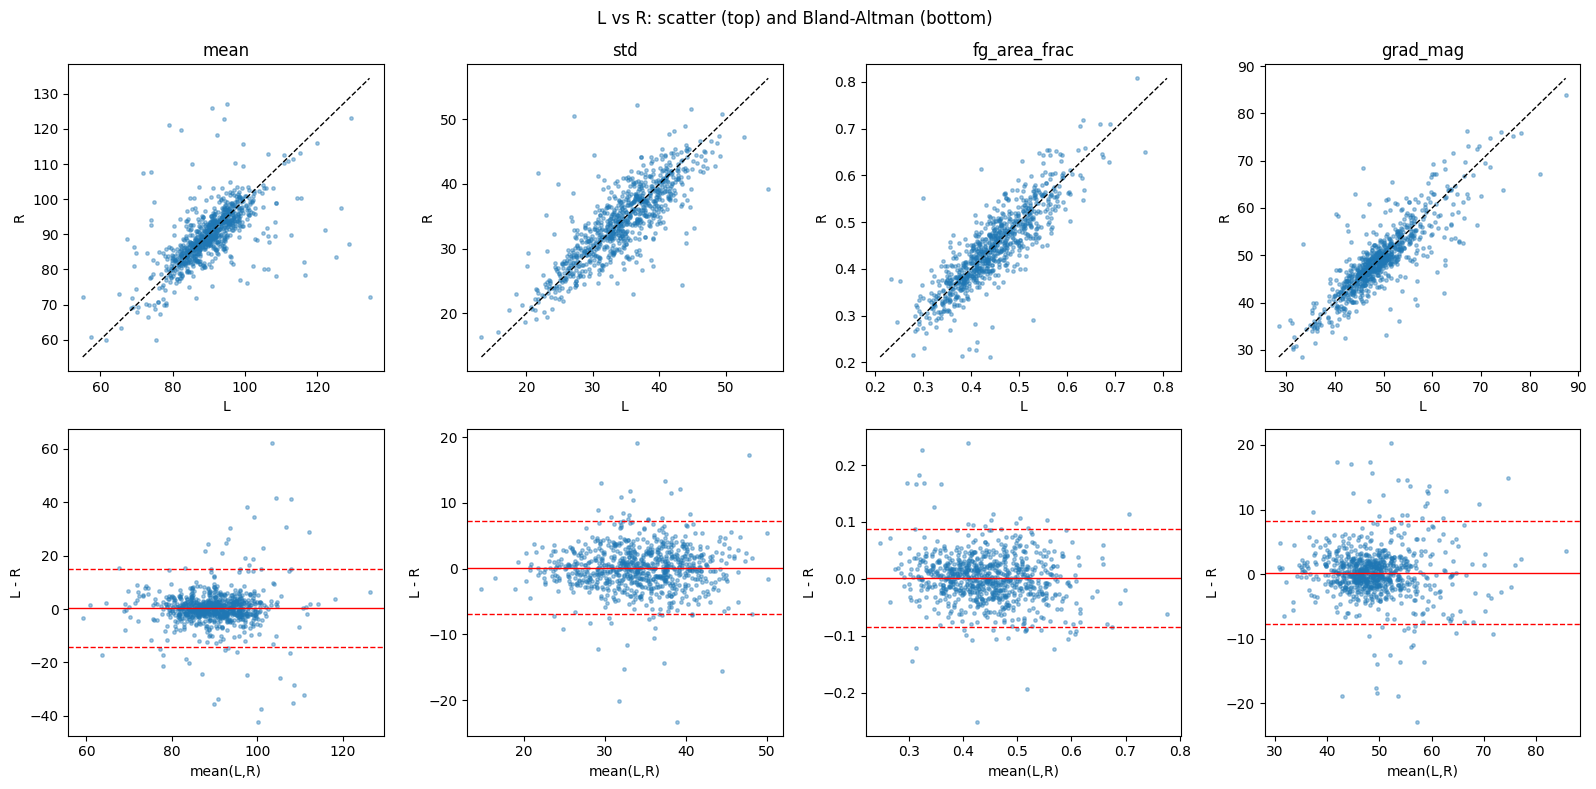

In [11]:
# L-vs-R scatter (identity line) + Bland-Altman for key features.
key_feats = ["mean", "std", "fg_area_frac", "grad_mag"]
fig, axes = plt.subplots(2, len(key_feats), figsize=(4 * len(key_feats), 8))
for c, f in enumerate(key_feats):
    x = wideL.loc[common, f].values; y = wideR.loc[common, f].values
    axes[0, c].scatter(x, y, s=6, alpha=0.4)
    lo, hi = min(x.min(), y.min()), max(x.max(), y.max())
    axes[0, c].plot([lo, hi], [lo, hi], "k--", lw=1)
    axes[0, c].set_title(f); axes[0, c].set_xlabel("L"); axes[0, c].set_ylabel("R")
    mean_, diff_ = (x + y) / 2, x - y
    md_, sd_ = diff_.mean(), diff_.std(ddof=1)
    axes[1, c].scatter(mean_, diff_, s=6, alpha=0.4)
    for yv, ls in [(md_, "-"), (md_ + 1.96 * sd_, "--"), (md_ - 1.96 * sd_, "--")]:
        axes[1, c].axhline(yv, color="r", ls=ls, lw=1)
    axes[1, c].set_xlabel("mean(L,R)"); axes[1, c].set_ylabel("L - R")
fig.suptitle("L vs R: scatter (top) and Bland-Altman (bottom)")
plt.tight_layout(); plt.savefig(FIG_DIR / "scatter_blandaltman.png", dpi=120); plt.show()

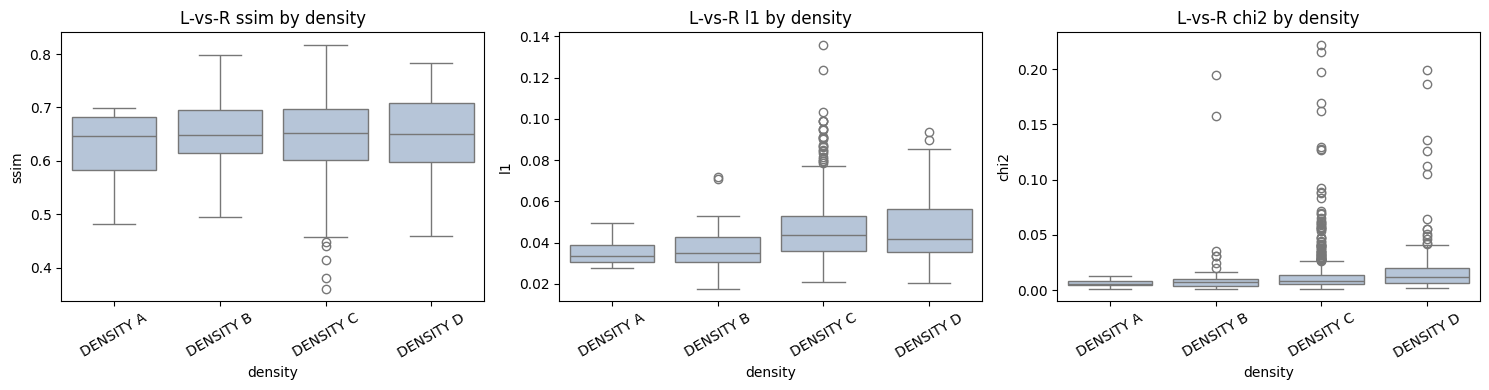

Baseline L-vs-R gap (pooled):


,ssim,l1,chi2
count,813.0000,813.0000,813.0000
mean,0.6460,0.0455,0.0151
std,0.0692,0.0149,0.0246
min,0.3598,0.0175,0.0009
25%,0.6020,0.0350,0.0052
50%,0.6520,0.0427,0.0085
75%,0.6976,0.0520,0.0145
max,0.8178,0.1360,0.2221


In [12]:
# Per-study L-vs-R image-distance metrics: distribution overall and by density.
import seaborn as sns
metrics = ["ssim", "l1", "chi2"]
fig, axes = plt.subplots(1, len(metrics), figsize=(5 * len(metrics), 4))
order = [d for d in DENSITY_ORDER if d in set(dist.density.dropna())]
for ax, mname in zip(axes, metrics):
    sns.boxplot(data=dist[dist.density.isin(order)], x="density", y=mname,
                order=order, ax=ax, color="lightsteelblue")
    ax.set_title(f"L-vs-R {mname} by density")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.savefig(FIG_DIR / "distance_by_density.png", dpi=120); plt.show()

print("Baseline L-vs-R gap (pooled):")
display(dist[metrics].describe().round(4))

## 5. Model-output comparison: L vs R, G(L) vs R, G(L) vs G(R)

On the **same studies** (one results folder) we compare three pairs, using the saved channels
`real_A` (L), `real_B` (R), `fake_B` = G(L), `fake_A` = G(R):

1. **L vs R** — `real_A` vs `real_B` (the original anatomical gap; baseline).
2. **G(L) vs R** — `fake_B` vs `real_B` (does translating L make it match the true right?).
3. **G(L) vs G(R)** — `fake_B` vs `fake_A` (do the two translations agree?).

Comparison 3 needs `fake_A`, which only exists in **bidirectional** runs; with a
unidirectional folder it is skipped automatically.

> **Frame alignment.** Each channel is loaded into the left-aligned frame: if its breast sits
> on the right half (center-of-mass > 0.5) it is flipped horizontally. So whether a run saved
> the right breast raw or pre-flipped, all four channels end up overlaid.

In [13]:
def discover_subdirs(rd):
    return [s for s in ["real_A", "fake_B", "real_B", "fake_A"] if (Path(rd) / s).is_dir()]

def ids_in(rd, sub):
    return {p.stem for p in (Path(rd) / sub).glob("*.png")}

def _com_x(u8):
    "Horizontal centre-of-mass of the breast (bright pixels), normalized to [0,1]."
    m = u8 > u8.mean(); xs = np.where(m)[1]
    return xs.mean() / u8.shape[1] if xs.size else 0.5

def load_aligned(rd, sub, iid):
    "Load a saved channel into the left-aligned [-1,1] frame (flip if breast on the right)."
    u = cv2.imread(str(Path(rd) / sub / f"{iid}.png"), cv2.IMREAD_GRAYSCALE)
    if u is None:
        return None
    if _com_x(u) > 0.5:
        u = cv2.flip(u, 1)
    return u.astype(np.float32) / 127.5 - 1.0

# Comparison name -> (channel A, channel B)
CASES = [("L_vs_R", "real_A", "real_B"),
         ("GL_vs_R", "fake_B", "real_B"),
         ("GL_vs_GR", "fake_B", "fake_A")]
CASE_LABELS = {"L_vs_R": "L vs R", "GL_vs_R": "G(L) vs R", "GL_vs_GR": "G(L) vs G(R)"}

assert RESULTS_DIR.exists(), f"results dir not found: {RESULTS_DIR}"
have = set(discover_subdirs(RESULTS_DIR))
active_cases = [(n, a, b) for (n, a, b) in CASES if a in have and b in have]
print("available channels:", sorted(have))
print("comparisons:", [CASE_LABELS[n] for n, _, _ in active_cases])

needed = sorted(set().union(*[{a, b} for _, a, b in active_cases]))
common_ids = None
for s in needed:
    common_ids = ids_in(RESULTS_DIR, s) if common_ids is None else common_ids & ids_in(RESULTS_DIR, s)
common_ids = sorted(common_ids)
print("studies:", len(common_ids))

cmp_rows = []
diffsum = {n: None for n, _, _ in active_cases}
diffcnt = 0
for iid in common_ids:
    imgs, ok = {}, True
    for s in needed:
        a = load_aligned(RESULTS_DIR, s, iid)
        if a is None:
            ok = False; break
        imgs[s] = a
    if not ok:
        continue
    dens = meta.at[iid, "breast_density"] if iid in meta.index else "UNKNOWN"
    for n, a, b in active_cases:
        d = pair_distances(imgs[a], imgs[b])
        cmp_rows.append({"image_id": iid, "density": dens, "comparison": n, **d})
        ad = np.abs(to_unit(imgs[a]) - to_unit(imgs[b]))
        diffsum[n] = ad if diffsum[n] is None else diffsum[n] + ad
    diffcnt += 1

cmp = pd.DataFrame(cmp_rows)
cmpw = cmp.pivot_table(index=["image_id", "density"], columns="comparison",
                       values=["ssim", "l1", "l2", "chi2"])
cmpw.columns = [f"{m}__{c}" for m, c in cmpw.columns]
cmpw = cmpw.reset_index()
print("scored studies:", diffcnt, "| rows:", len(cmp))
display(cmp.groupby("comparison")[["ssim", "l1", "l2", "chi2"]].median()
        .reindex([n for n, _, _ in active_cases]).round(4))

available channels: ['fake_A', 'fake_B', 'real_A', 'real_B']
comparisons: ['L vs R', 'G(L) vs R', 'G(L) vs G(R)']
studies: 200
scored studies: 200 | rows: 600


,ssim,l1,l2,chi2
comparison,,,,
L_vs_R,0.6539,0.0431,0.0834,0.0080
GL_vs_R,0.6713,0.0401,0.0804,0.0152
GL_vs_GR,0.6975,0.0349,0.0707,0.0108


In [14]:
# Paired Wilcoxon of each translation comparison against the L-vs-R baseline (same studies).
case_order = [n for n, _, _ in active_cases]
others = [n for n in case_order if n != "L_vs_R"]

def paired_vs_baseline(w, metric, case, base="L_vs_R"):
    a = w[f"{metric}__{case}"].values; b = w[f"{metric}__{base}"].values
    try:
        _, p = wilcoxon(a, b)
    except ValueError:
        p = np.nan
    return {"metric": metric, "comparison": case, "n": len(a),
            "median_case": float(np.median(a)), "median_baseline": float(np.median(b)),
            "median_delta": float(np.median(a - b)), "wilcoxon_p": float(p)}

rows = []
for stratum, w in [("ALL", cmpw)] + [(d, cmpw[cmpw.density == d]) for d in DENSITY_ORDER]:
    if len(w) < 5:
        continue
    for metric in ["ssim", "l1"]:
        for case in others:
            if f"{metric}__{case}" in w.columns:
                r = paired_vs_baseline(w, metric, case); r["stratum"] = stratum; rows.append(r)
cmp_stats = pd.DataFrame(rows)[["stratum", "metric", "comparison", "n",
                                "median_baseline", "median_case", "median_delta", "wilcoxon_p"]]
print("vs L-vs-R baseline  (SSIM: delta>0 => closer; L1: delta<0 => closer)")
display(cmp_stats[cmp_stats.stratum == "ALL"].round(4).set_index(["metric", "comparison"]))

vs L-vs-R baseline  (SSIM: delta>0 => closer; L1: delta<0 => closer)


stratum    n  median_baseline  median_case  median_delta  \
metric comparison                                                            
ssim   GL_vs_R        ALL  200           0.6539       0.6713        0.0150   
       GL_vs_GR       ALL  200           0.6539       0.6975        0.0446   
l1     GL_vs_R        ALL  200           0.0431       0.0401       -0.0020   
       GL_vs_GR       ALL  200           0.0431       0.0349       -0.0070   

                   wilcoxon_p  
metric comparison              
ssim   GL_vs_R            0.0  
       GL_vs_GR           0.0  
l1     GL_vs_R            0.0  
       GL_vs_GR           0.0

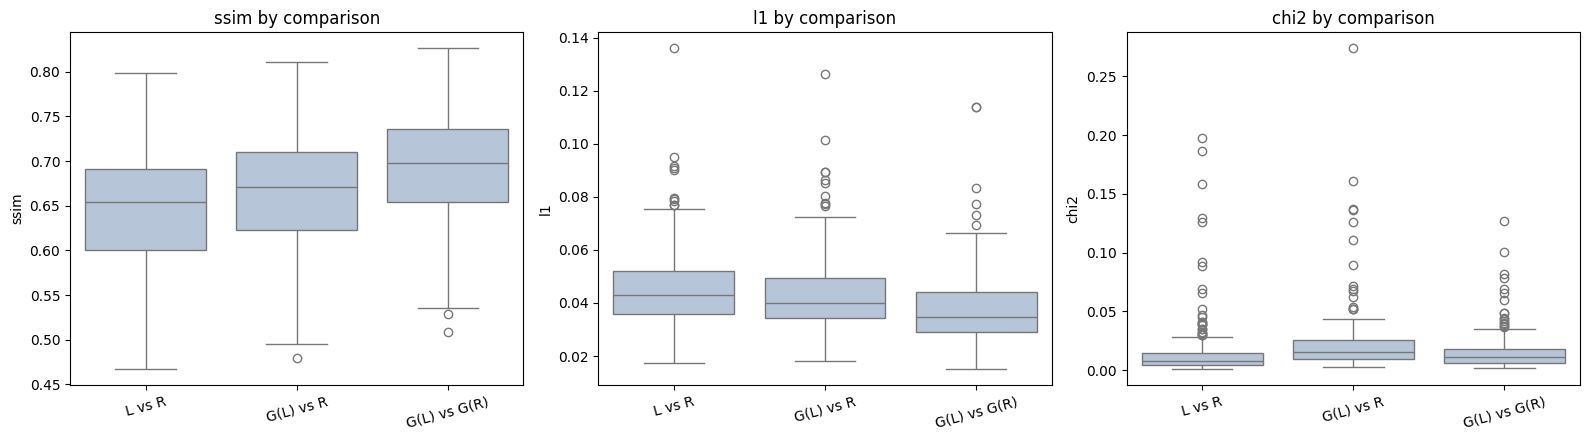

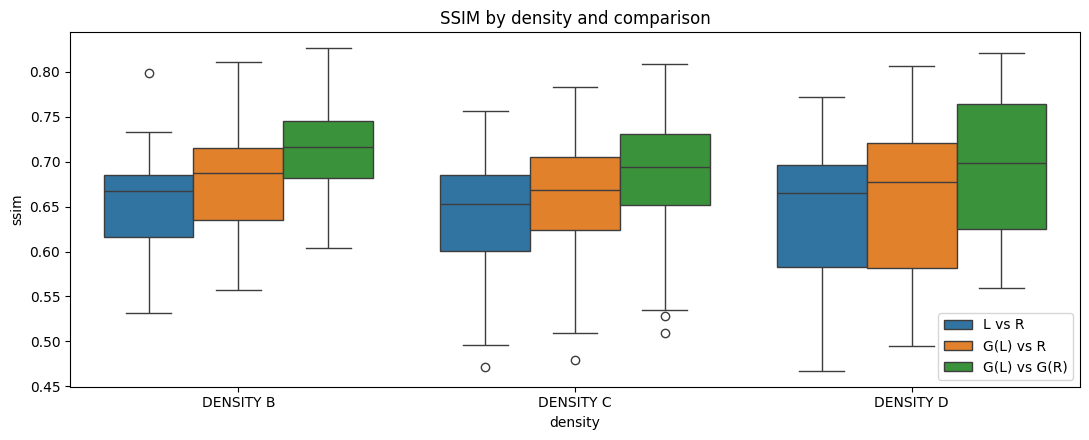

In [15]:
# Distance distributions across the three comparisons (pooled + SSIM by density).
import seaborn as sns
labels = [CASE_LABELS[n] for n in case_order]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, metric in zip(axes, ["ssim", "l1", "chi2"]):
    sns.boxplot(data=cmp, x="comparison", y=metric, order=case_order, ax=ax, color="lightsteelblue")
    ax.set_xticklabels(labels, rotation=15); ax.set_title(f"{metric} by comparison"); ax.set_xlabel("")
plt.tight_layout(); plt.savefig(FIG_DIR / "compare_cases_box.png", dpi=120); plt.show()

order_d = [d for d in DENSITY_ORDER if d in set(cmp.density)]
fig, ax = plt.subplots(figsize=(11, 4.5))
sns.boxplot(data=cmp[cmp.density.isin(order_d)], x="density", y="ssim",
            hue="comparison", order=order_d, hue_order=case_order, ax=ax)
h, _ = ax.get_legend_handles_labels(); ax.legend(h, labels, title="")
ax.set_title("SSIM by density and comparison")
plt.tight_layout(); plt.savefig(FIG_DIR / "compare_cases_ssim_by_density.png", dpi=120); plt.show()

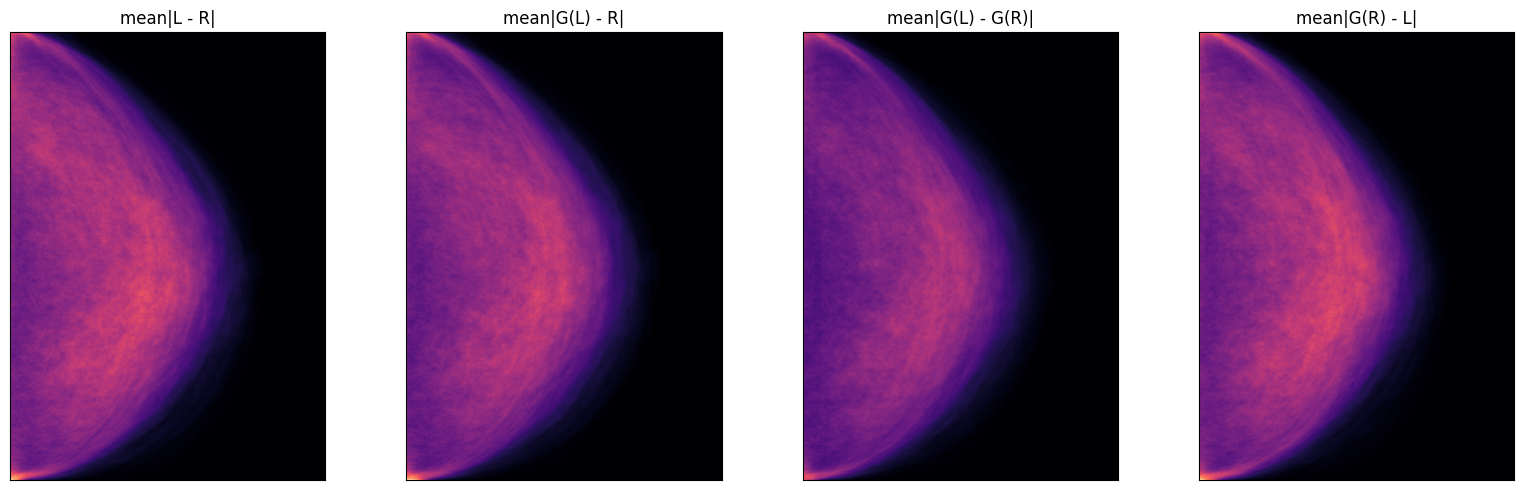

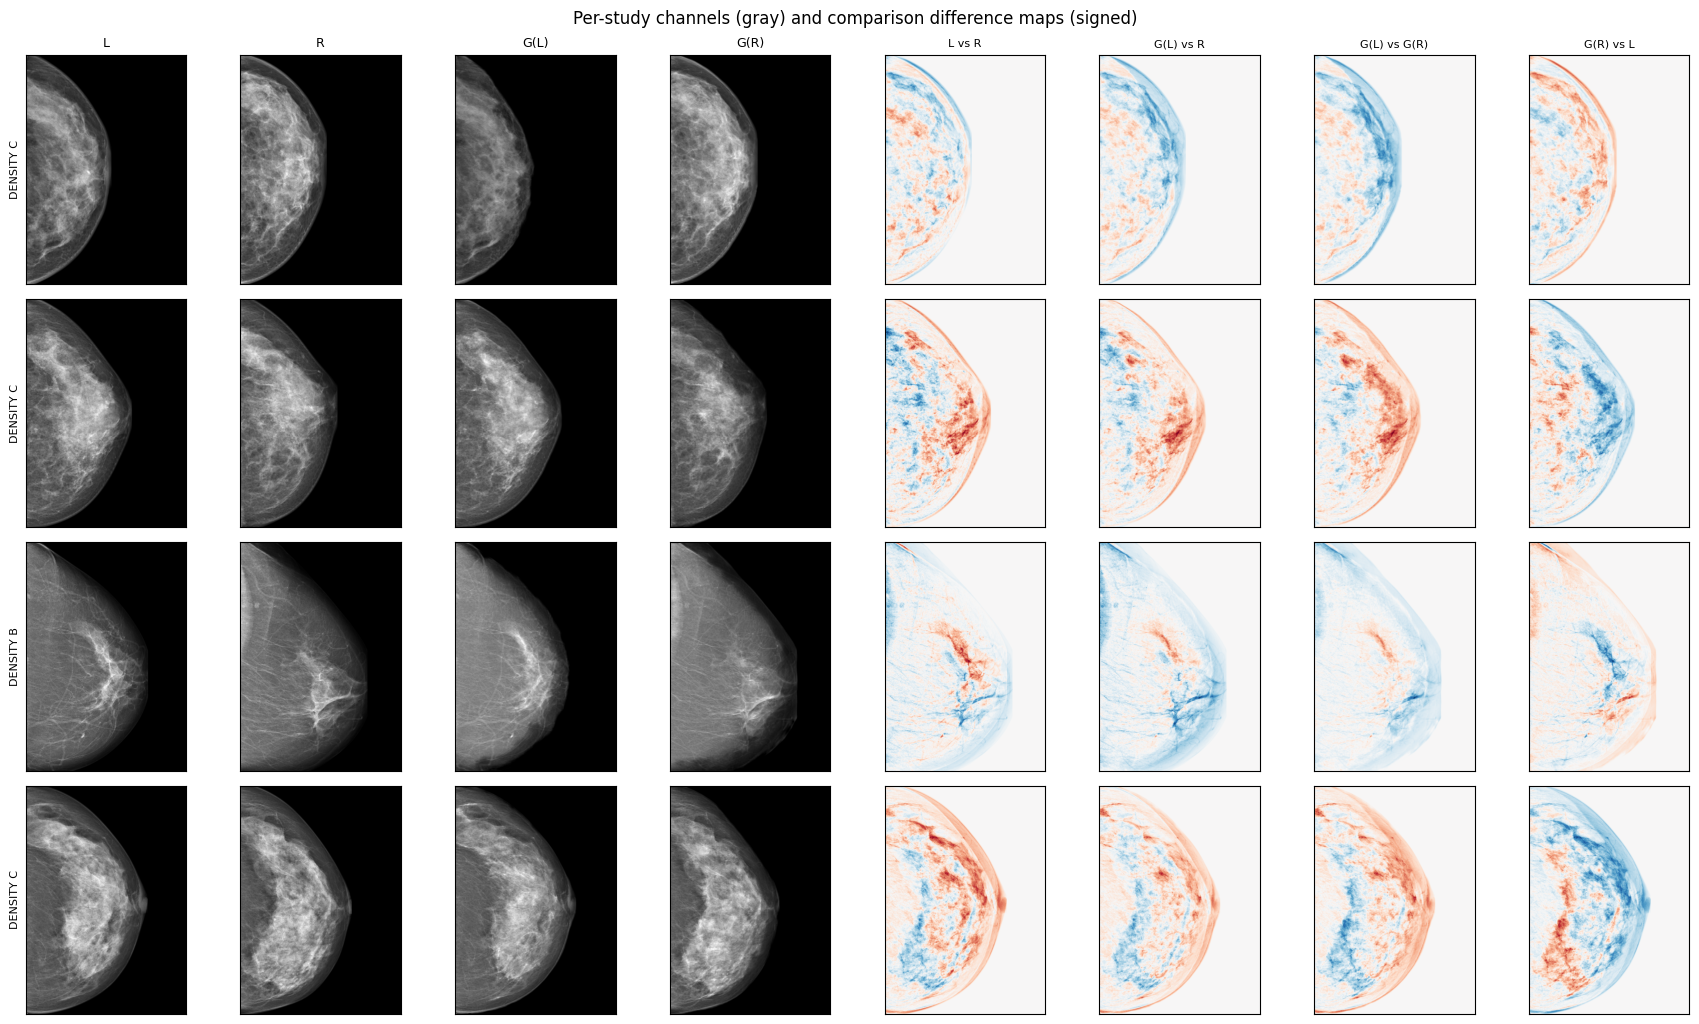

In [20]:
# Mean |difference| maps per comparison, and representative per-study panels.
# Add G(R) - L (fake_A vs real_A) as the last column alongside the cell-19 comparisons.
extra = [("GR_vs_L", "fake_A", "real_A")] if {"fake_A", "real_A"} <= have else []
fig_cases = active_cases + extra
fig_labels = {**CASE_LABELS, "GR_vs_L": "G(R) vs L"}

# diffsum (from cell 19) covers active_cases only; accumulate the extra case here.
fig_diffsum = dict(diffsum)
for n, a, b in extra:
    acc = None
    for iid in common_ids:
        ia, ib = load_aligned(RESULTS_DIR, a, iid), load_aligned(RESULTS_DIR, b, iid)
        if ia is None or ib is None:
            continue
        ad = np.abs(to_unit(ia) - to_unit(ib))
        acc = ad if acc is None else acc + ad
    fig_diffsum[n] = acc

vmax = max((fig_diffsum[n] / diffcnt).max() for n, _, _ in fig_cases)
fig, axes = plt.subplots(1, len(fig_cases), figsize=(4 * len(fig_cases), 5))
axes = np.atleast_1d(axes)
for ax, (n, _, _) in zip(axes, fig_cases):
    ax.imshow(fig_diffsum[n] / diffcnt, cmap="magma", vmin=0, vmax=vmax)
    ax.set_title("mean|" + fig_labels[n].replace(" vs ", " - ") + "|")
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.savefig(FIG_DIR / "compare_cases_maps.png", dpi=120); plt.show()

chans = [(s, t) for s, t in [("real_A", "L"), ("real_B", "R"),
                             ("fake_B", "G(L)"), ("fake_A", "G(R)")] if s in have]
sel_ids = [common_ids[i] for i in np.linspace(0, len(common_ids) - 1, 4).astype(int)]
ncol = len(chans) + len(fig_cases)
fig, axes = plt.subplots(len(sel_ids), ncol, figsize=(2.2 * ncol, 2.6 * len(sel_ids)))
axes = np.atleast_2d(axes)
for r, iid in enumerate(sel_ids):
    imgs = {s: load_aligned(RESULTS_DIR, s, iid) for s, _ in chans}
    c = 0
    for s, t in chans:
        axes[r, c].imshow(to_uint8(imgs[s]), cmap="gray")
        if r == 0:
            axes[r, c].set_title(t, fontsize=9)
        c += 1
    for n, a, b in fig_cases:
        diff = to_unit(imgs[a]) - to_unit(imgs[b]); mm = np.abs(diff).max() + 1e-8
        axes[r, c].imshow(diff, cmap="RdBu_r", vmin=-mm, vmax=mm)
        if r == 0:
            axes[r, c].set_title(fig_labels[n], fontsize=8)
        c += 1
    dens = meta.at[iid, "breast_density"] if iid in meta.index else "?"
    axes[r, 0].set_ylabel(dens, fontsize=8)
    for cc in range(ncol):
        axes[r, cc].set_xticks([]); axes[r, cc].set_yticks([])
fig.suptitle("Per-study channels (gray) and comparison difference maps (signed)")
plt.tight_layout(); plt.savefig(FIG_DIR / "compare_cases_examples.png", dpi=120); plt.show()

## 6. Summary

In [17]:
# Persist the tables for the write-up.
feat.to_csv(FIG_DIR / "per_side_features.csv", index=False)
dist.to_csv(FIG_DIR / "per_study_LR_distances.csv", index=False)
stats_df.to_csv(FIG_DIR / "paired_feature_stats.csv", index=False)
cmp.to_csv(FIG_DIR / "model_comparison_per_study.csv", index=False)
cmp_stats.to_csv(FIG_DIR / "model_comparison_stats.csv", index=False)
print("Saved tables + figures to:", FIG_DIR)

print("\n=== Significant paired L-vs-R features (pooled, BH q<0.05) ===")
sig = stats_df[(stats_df.stratum == "ALL") & (stats_df.wilcoxon_q < 0.05)]
display(sig[["feature", "median_diff", "cohen_dz", "wilcoxon_q"]].round(4))

print("=== Median distance by comparison (pooled) ===")
display(cmp.groupby("comparison")[["ssim", "l1", "l2", "chi2"]].median()
        .reindex([n for n, _, _ in active_cases]).round(4))

print("=== Translation comparisons vs L-vs-R baseline (pooled) ===")
display(cmp_stats[cmp_stats.stratum == "ALL"].round(4).set_index(["metric", "comparison"]))

Saved tables + figures to: /home/valery/phd/contrastive-unpaired-translation/figures/laterality_analysis-patchnce

=== Significant paired L-vs-R features (pooled, BH q<0.05) ===


,feature,median_diff,cohen_dz,wilcoxon_q


=== Median distance by comparison (pooled) ===


,ssim,l1,l2,chi2
comparison,,,,
L_vs_R,0.6539,0.0431,0.0834,0.0080
GL_vs_R,0.6713,0.0401,0.0804,0.0152
GL_vs_GR,0.6975,0.0349,0.0707,0.0108


=== Translation comparisons vs L-vs-R baseline (pooled) ===


stratum    n  median_baseline  median_case  median_delta  \
metric comparison                                                            
ssim   GL_vs_R        ALL  200           0.6539       0.6713        0.0150   
       GL_vs_GR       ALL  200           0.6539       0.6975        0.0446   
l1     GL_vs_R        ALL  200           0.0431       0.0401       -0.0020   
       GL_vs_GR       ALL  200           0.0431       0.0349       -0.0070   

                   wilcoxon_p  
metric comparison              
ssim   GL_vs_R            0.0  
       GL_vs_GR           0.0  
l1     GL_vs_R            0.0  
       GL_vs_GR           0.0

## Appendix: live `netG` inference (optional)

Set `RUN_LIVE_INFERENCE = True` and point `CKPT_NAME`/`EPOCH` at a checkpoint under
`checkpoints/<name>/` to translate left images on the fly instead of using saved results.
Mirrors the model-loading pattern in `colab_test_fastcut_bidirectional.ipynb`.

In [18]:
RUN_LIVE_INFERENCE = False  # requires a local checkpoints/<name>/<epoch>_net_G.pth

if RUN_LIVE_INFERENCE:
    import torch
    from models import create_model
    from options.test_options import TestOptions

    CKPT_NAME, EPOCH = "vindr_bilateral_smoke", "latest"
    # Construct opts the same way test.py does, e.g.:
    #   args = ["--dataroot", DATA_ROOT, "--name", CKPT_NAME, "--model", "cut",
    #           "--CUT_mode", "CUT", "--dataset_mode", "bilateral",
    #           "--annotations_csv", ANNOTATIONS_CSV, "--split", SPLIT,
    #           "--bilateral_size", "512", "384", "--epoch", EPOCH, "--eval"]
    #   opt = TestOptions().parse(args)         # depends on this repo's parse() signature
    #   model = create_model(opt); model.setup(opt); model.eval()
    #   netG = model.netG
    #   L, R = load_pair_aligned(0)
    #   with torch.no_grad():
    #       fake = netG(torch.from_numpy(L)[None].to(model.device))
    print("Live inference template — fill in opts/checkpoint to run.")
else:
    print("RUN_LIVE_INFERENCE is False; using saved results from section 5.")

RUN_LIVE_INFERENCE is False; using saved results from section 5.
